<a href="https://colab.research.google.com/github/agustinasriastuti-ds/analisis-kepuasan-dosen/blob/main/Lecturer_Satisfaction_Analysis_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#  Import semua library penting
from google.colab import files
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
df = pd.read_excel('tb_20232 REV.01.xlsx', sheet_name='tb_20232')

In [ ]:
df.head()

In [ ]:
df.shape[1]

In [ ]:
df.shape[0]

In [ ]:
# Baca data dari sheet
df = pd.read_excel('tb_20232 REV.01.xlsx', sheet_name='tb_20232')

# Simpan kolom penting
df['NIM'] = df['NPM']
df['Dosen'] = df['Namadosen']

# Ambil kolom pertanyaan
X = df[['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10']]

In [ ]:
# Ambil hanya kolom p1 - p10
X = df[['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9', 'p10']]

# Normalisasi data (penting agar setiap fitur seimbang)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA - Reduksi dimensi ke 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

# t-SNE - Visualisasi non-linear dengan parameter lengkap
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42,
    init='pca'  # bisa ditambahkan untuk inisialisasi lebih stabil
)
X_tsne = tsne.fit_transform(X_scaled)
df['TSNE1'] = X_tsne[:, 0]
df['TSNE2'] = X_tsne[:, 1]

In [ ]:
plt.figure(figsize=(18, 7))

# --- Grafik PCA ---
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Namadosen', palette='tab20', s=50)
plt.title('📊 PCA - Penilaian Mahasiswa')
plt.xlabel('Komponen 1')
plt.ylabel('Komponen 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

# --- Grafik t-SNE ---
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='Namadosen', palette='tab20', s=50)
plt.title('🌀 t-SNE - Penilaian Mahasiswa')
plt.xlabel('Dimensi 1')
plt.ylabel('Dimensi 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22, 8))  #  Lebarkan ukuran agar legend tidak menumpuk

#  PCA
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Namadosen', palette='tab20', s=50, legend='full')
plt.title('📊 PCA - Penilaian Mahasiswa', fontsize=14)
plt.xlabel('Komponen 1')
plt.ylabel('Komponen 2')
plt.grid(True)

# Legend keluar dari area plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=9)

# t-SNE
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='Namadosen', palette='tab20', s=50, legend='full')
plt.title('🌀 t-SNE - Penilaian Mahasiswa', fontsize=14)
plt.xlabel('Dimensi 1')
plt.ylabel('Dimensi 2')
plt.grid(True)

# Legend keluar dari area plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Perbesar area figure agar muat semua legend
plt.figure(figsize=(25, 10))

# --- PCA ---
ax1 = plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Namadosen', palette='tab20', s=50, legend='full', ax=ax1)
ax1.set_title('📊 PCA - Penilaian Mahasiswa', fontsize=14)
ax1.set_xlabel('Komponen 1')
ax1.set_ylabel('Komponen 2')
ax1.grid(True)

# --- t-SNE ---
ax2 = plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='Namadosen', palette='tab20', s=50, legend='full', ax=ax2)
ax2.set_title('🌀 t-SNE - Penilaian Mahasiswa', fontsize=14)
ax2.set_xlabel('Dimensi 1')
ax2.set_ylabel('Dimensi 2')
ax2.grid(True)

# --- Atur legend agar tidak menumpuk ---
handles, labels = ax2.get_legend_handles_labels()
plt.legend(
    handles, labels,
    bbox_to_anchor=(0.5, -0.15),    # posisi legend DI BAWAH plot
    loc='upper center',
    ncol=5,                         #  jumlah kolom legend (bisa di ubah 4, 6, dst)
    fontsize=9,
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # beri ruang untuk legend bawah
plt.show()


In [ ]:
import plotly.express as px

fig = px.scatter(df, x='PC1', y='PC2', color='Namadosen', title='📊 PCA')
fig.show()


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Ambil hanya p1 - p10
X = df[['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10']]

# Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA ke 2 dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Tambahkan hasil ke dataframe
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]


In [ ]:
import pandas as pd
import numpy as np

# Membuat dataframe kontribusi PCA
loadings = pd.DataFrame(
    pca.components_.T,              # transpose biar kolom = PC1, PC2
    columns=['PC1', 'PC2'],
    index=['p1','p2','p3','p4','p5','p6','p7','p8','p9','p10']
)

# Tambahkan kolom 'Dominan di' untuk melihat kontribusi terbesar
loadings['Dominan_di'] = np.where(abs(loadings['PC1']) > abs(loadings['PC2']), 'PC1', 'PC2')

print(loadings)


In [ ]:
import matplotlib.pyplot as plt

loadings[['PC1','PC2']].plot(kind='bar', figsize=(10,6))
plt.title("Kontribusi Pertanyaan terhadap PC1 dan PC2")
plt.ylabel("Loading Value")
plt.xlabel("Pertanyaan (p1 - p10)")
plt.xticks(rotation=0)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))  #  Lebarkan ukuran agar legend tidak menumpuk

#  PCA
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Namadosen', palette='tab20', s=50, legend='full')
plt.title('📊 PCA - Student Evaluation', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

# Legend keluar dari area plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=9)

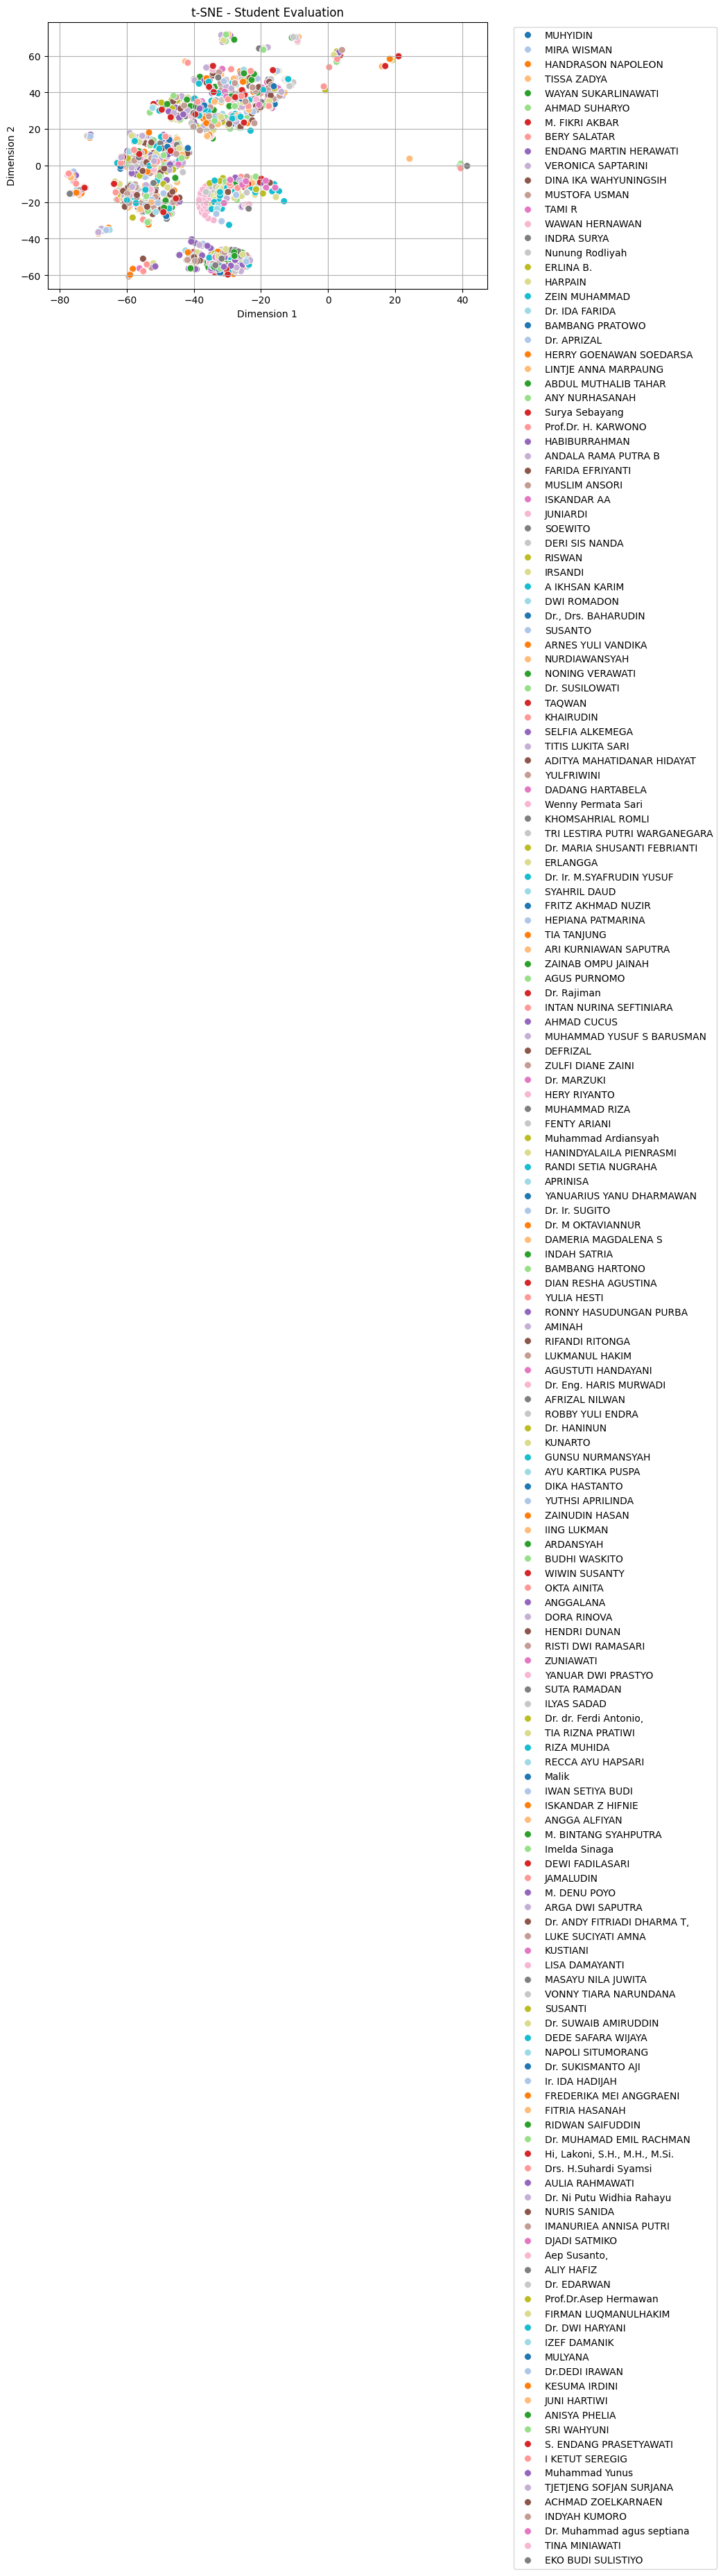

In [29]:
# --- Grafik t-SNE ---
plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='TSNE1', y='TSNE2', hue='Namadosen', palette='tab20', s=50)
plt.title('t-SNE - Student Evaluation')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.show()

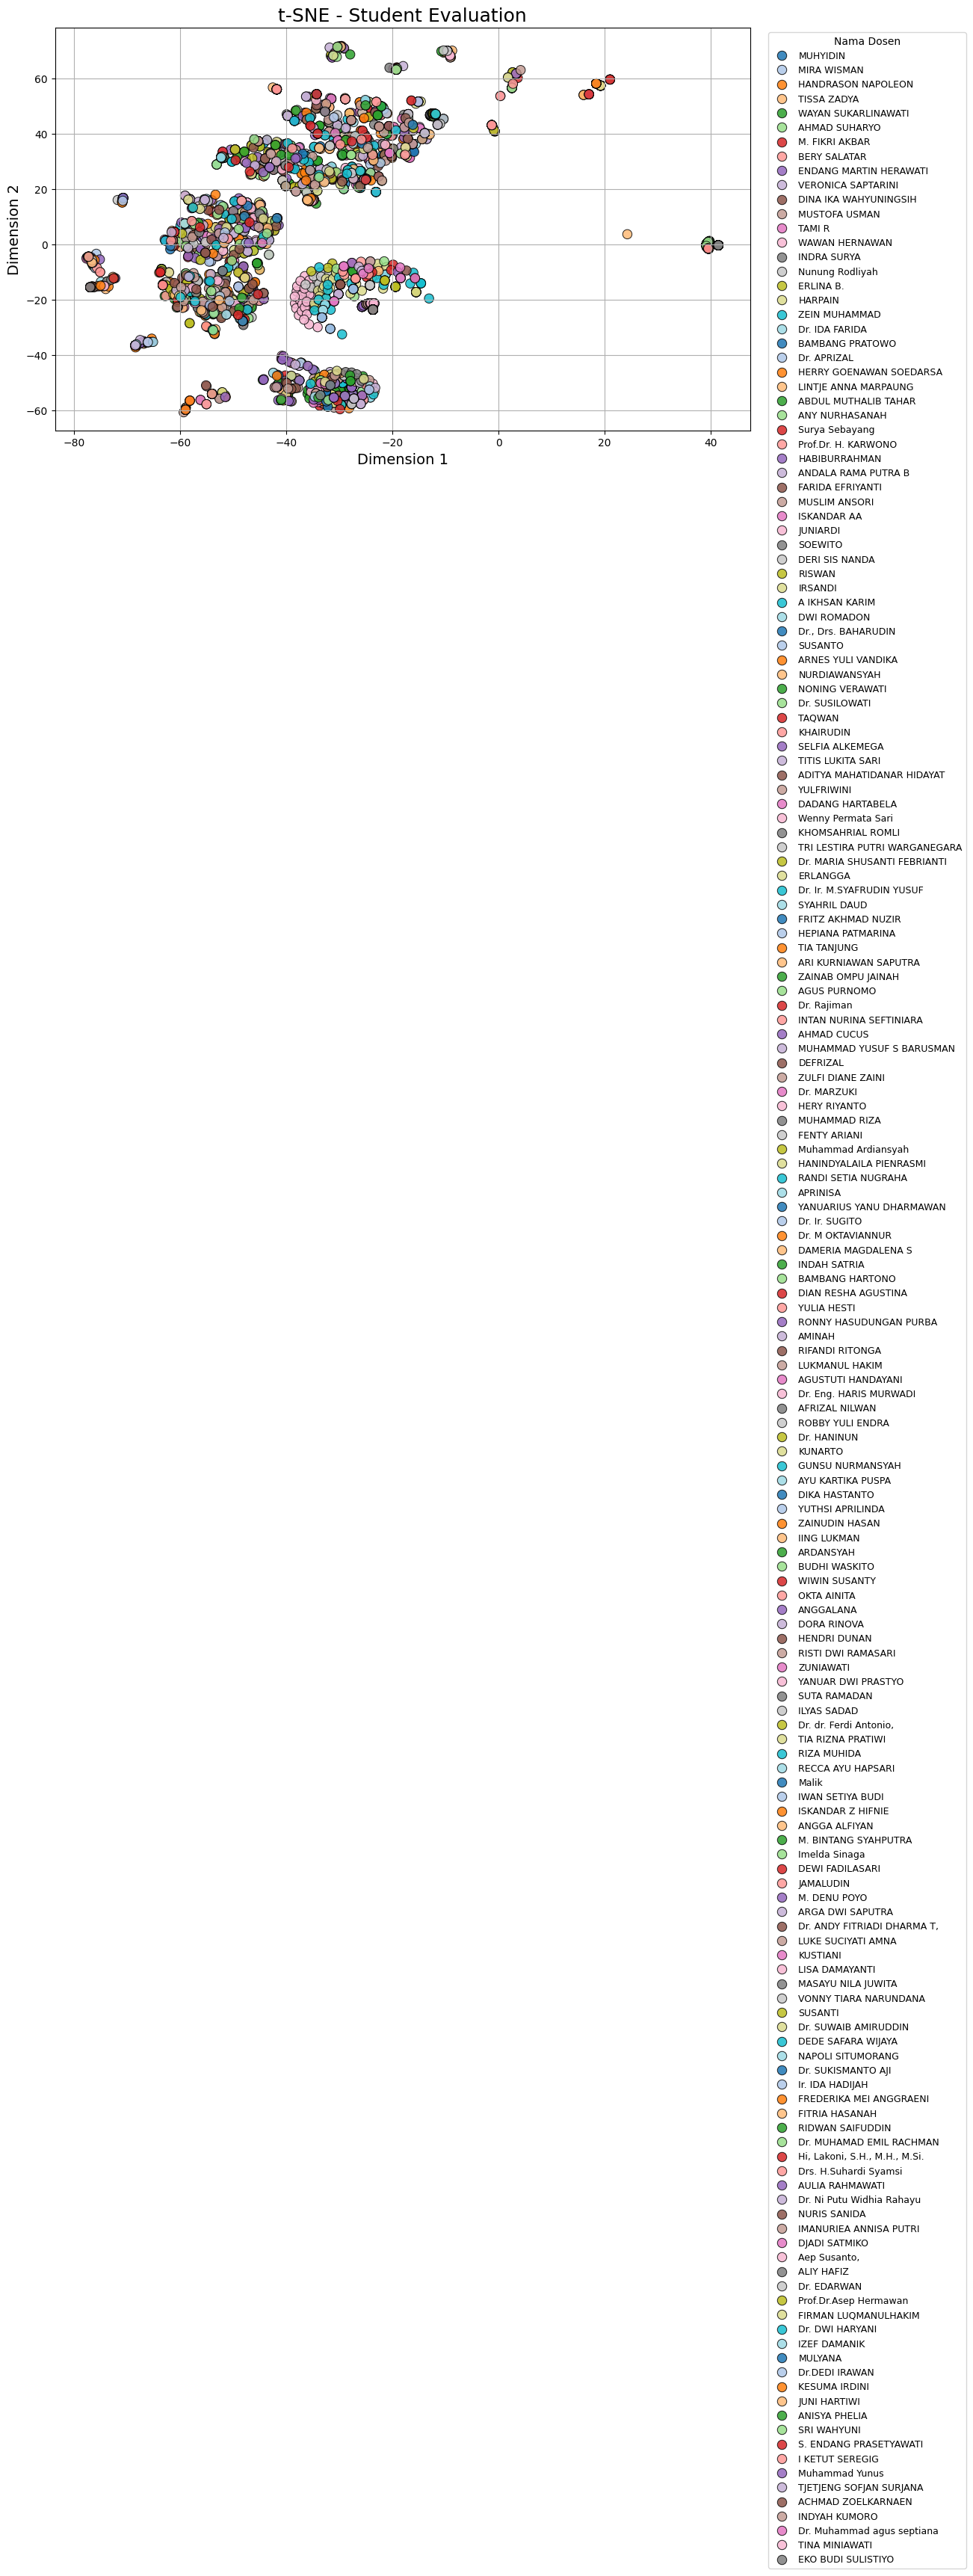

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Perbesar ukuran figure
plt.figure(figsize=(12, 7))

# Scatter plot t-SNE
sns.scatterplot(
    data=df,
    x='TSNE1',
    y='TSNE2',
    hue='Namadosen',
    palette='tab20',
    s=80,              # Perbesar titik
    edgecolor='black', # Tambah outline biar jelas
    alpha=0.85
)

plt.title('t-SNE - Student Evaluation', fontsize=18)
plt.xlabel('Dimension 1', fontsize=14)
plt.ylabel('Dimension 2', fontsize=14)

plt.grid(True)

# Legend di luar dan dibuat lebih rapi
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=9,
    title='Nama Dosen'
)

plt.show()


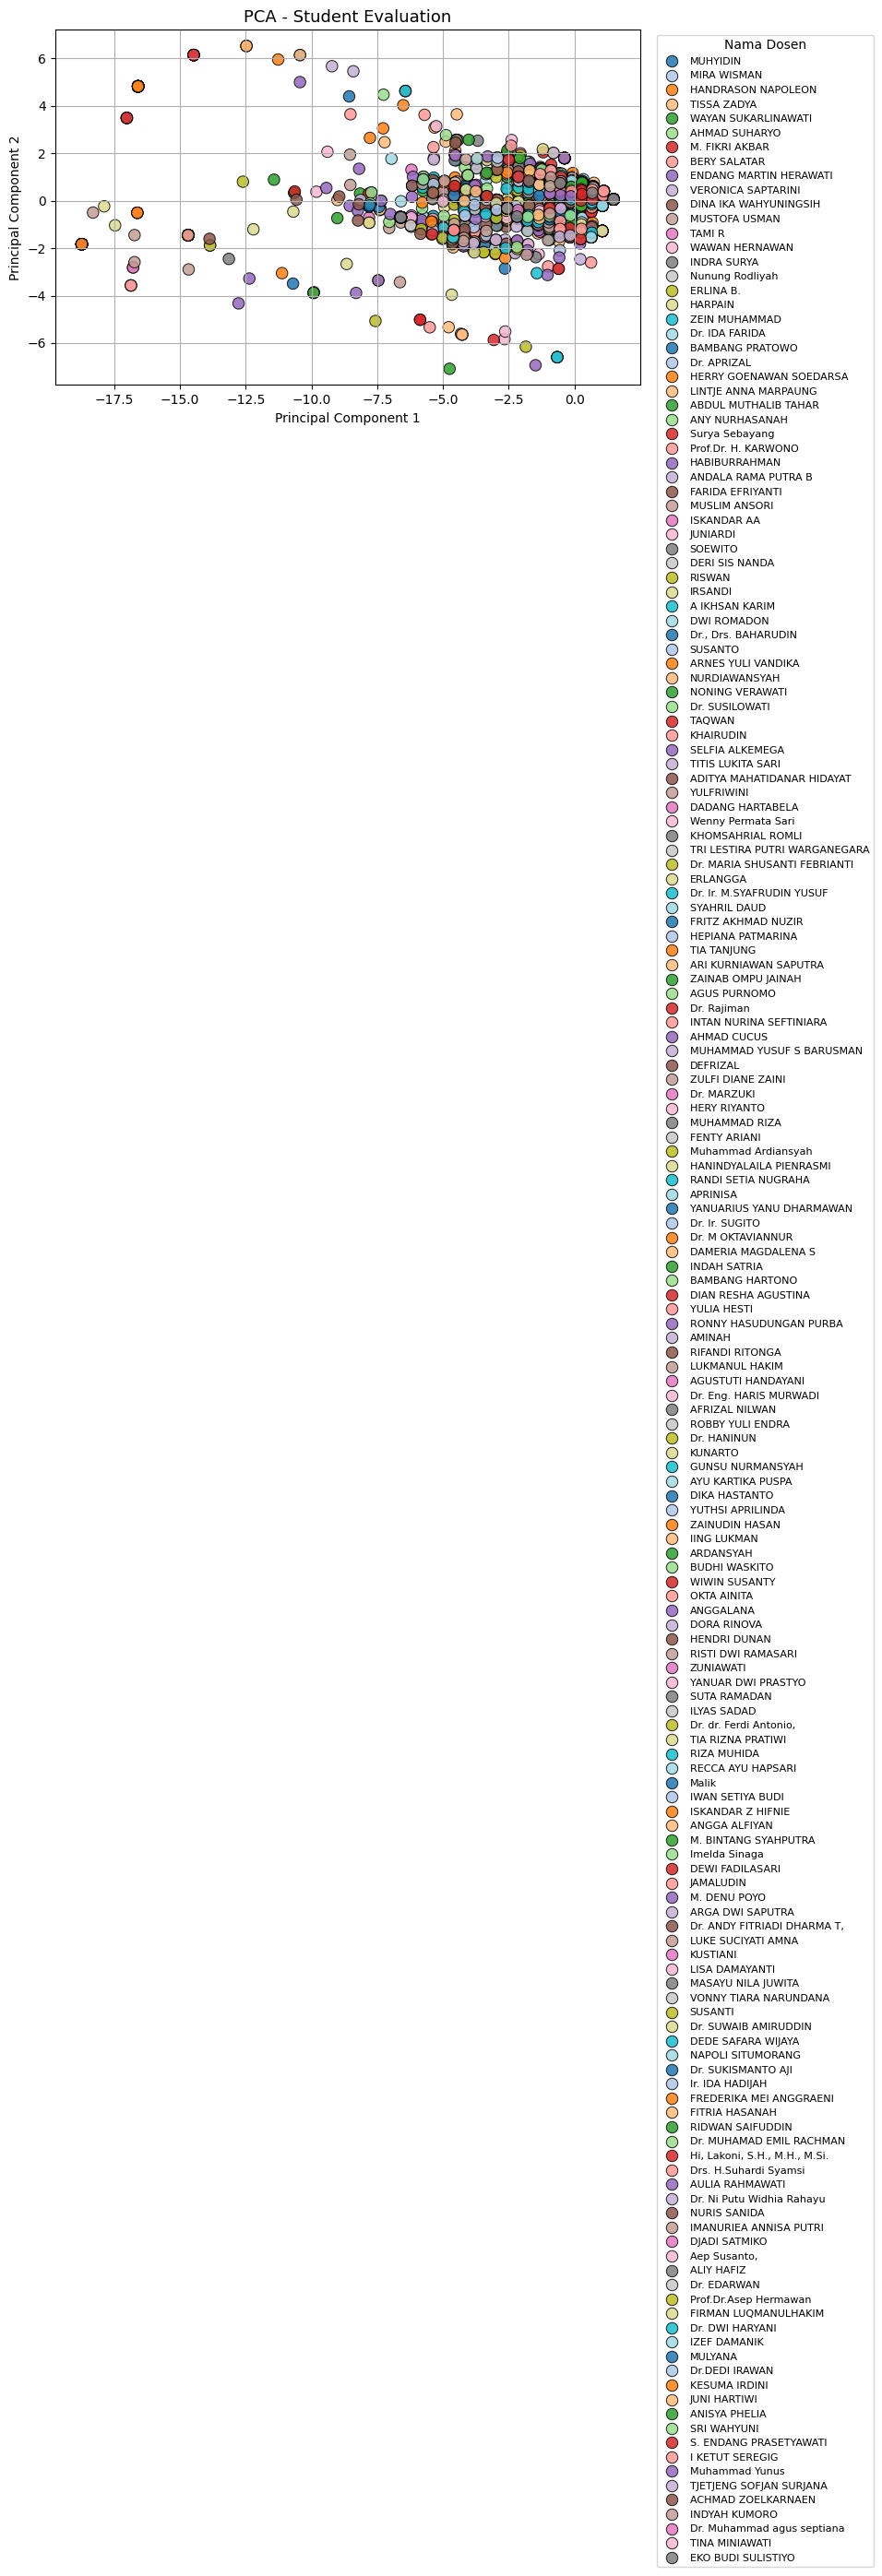

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))  # Perbesar ukuran keseluruhan

# ======================
# PCA
# ======================
plt.subplot(1, 2, 1)

sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='Namadosen',
    palette='tab20',
    s=80,              # Perbesar titik
    edgecolor='black', # Tambah outline agar jelas
    alpha=0.85
)

plt.title('PCA - Student Evaluation', fontsize=13)
plt.xlabel('Principal Component 1', fontsize=10)
plt.ylabel('Principal Component 2', fontsize=10)

plt.grid(True)

# Legend keluar supaya lebih rapi
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=8,
    title='Nama Dosen'
)

plt.show()


In [25]:
print(X_pca)

[[ 1.48365003  0.05449667]
 [ 1.48365003  0.05449667]
 [-0.50547263  0.86154336]
 ...
 [ 1.48365003  0.05449667]
 [-2.55964772 -0.3226184 ]
 [ 1.48365003  0.05449667]]
